# Assignment 4 – CS5831: Advanced Data Mining

## Topic: Text Mining and Clustering

This assignment focuses on core concepts and practical implementation of **text mining** and **clustering techniques**.

---

### Submission Guidelines

- The notebook **must be named exactly**:  
  **`a4-5831.ipynb`**

- You are expected to use only the packages and tools specified in the assignment instructions or provided on Canvas.

- Use of any additional libraries or external tools **must receive prior approval from Dr. Roy** before submission.

Failure to follow naming conventions or tool restrictions may result in grading penalties.

In [1]:
# Import standard DS packages 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy
import statistics
import textwrap
%matplotlib inline


from sklearn.model_selection import train_test_split, StratifiedKFold 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import tree        # decision tree classifier
from sklearn import naive_bayes # naive bayes classifier 
from sklearn import ensemble    # ensemble classifiers
from sklearn import metrics     # performance evaluation metrics
from sklearn import model_selection
from sklearn import preprocessing 
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer

from sklearn import preprocessing
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn import cluster
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

import otter 
grader = otter.Notebook()

# Q1 - Text Classification 


You will look to predict whether scenes in Shakespeare's plays come from the comedies or histories.  Shakespeare's comedies include plays such as: The Taming of the Shrew, The Merchant of Venice, Much Ado About Nothing, and more.  The histories include: Richard II, Richard III, Henry IV part 1, Henry IV part 2, Henry V, Henry VI (part 1-3). 

The plays were downloaded from the [Shakespeare Corpus](http://hdl.handle.net/11040/24448).  Note, the original plays were downloaded from [Project Gutenberg](https://www.gutenberg.org/). 

Note, the plays have already had significant preprocessing.  The plays have been scrubbed by: removing digits, making the file all lowercase, and removing punctuation, excluding hyphens and word-internal apostrophes. Also, the character names and stage directions have been removed manually. An example of the text would be like this:

*Before scrubbing:*

    ADAM. Yonder comes my master, your brother.
    ORLANDO. Go apart, Adam, and thou shalt hear how he will shake me
    up. [ADAM retires]
    OLIVER. Now, sir! what make you here?

*After scrubbing:*

    yonder comes my master your brother
    go apart adam and thou shalt hear how he will shake me
    up
    now sir what make you here

The text files are split into negative - comedies and positive - histories.  


## Q1(a) - Load the Data 

Load the plays into a list `textdata` and a np.ndarray `yvalues`.  I highly suggest using `scikit-learn`'s `load_files` function, with the `random_state` set to 42.  

 

In [2]:
# Load the plays data     

plays = load_files(
    "data/shakespeare",
    random_state=42
)

textdata = plays.data

yvalues = np.array(plays.target)


print("Samples per class: {}".format(np.bincount(yvalues)))

plays.filenames[0:10]

Samples per class: [119 208]


array(['data/shakespeare/histories/henryVIpartiiActIIIScenei_noCNnoSD.txt',
       'data/shakespeare/comedies/twelfthNightActIScenei_noCNnoSD.txt',
       'data/shakespeare/histories/henryVIpartiiActIVSceneviii_noCNnoSD.txt',
       'data/shakespeare/comedies/asYouLikeItActIIScenev_noCNnoSD.txt',
       'data/shakespeare/comedies/tempestActIIISceneii_noCNnoSD.txt',
       'data/shakespeare/histories/henryVIpartiActIVSceneii_noCNnoSD.txt',
       'data/shakespeare/histories/henryVIpartiiiActIVSceneviii_noCNnoSD.txt',
       'data/shakespeare/histories/henryVIIIActVScenei_noCNnoSD.txt',
       'data/shakespeare/histories/henryVIpartiActIIIScenei_noCNnoSD.txt',
       'data/shakespeare/comedies/twelfthNightActIIIScenei_noCNnoSD.txt'],
      dtype='<U72')

In [3]:
grader.check("q1a")

q1a results: All test cases passed!

## Q1(b) - Prepare the Data 

Split the data into `text_trainval`, `text_test` and `y_trainval`, `y_test` variables.  Use 20% of the data in the test set with a `random_state` of 42 and make sure to stratify the split (the data is imbalanced). 

In [4]:
# Split the data 

text_trainval, text_test, y_trainval, y_test = train_test_split(textdata, yvalues, test_size=0.20, random_state=42, stratify=yvalues
)


In [5]:
grader.check("q1b")

q1b results: All test cases passed!

## Q1(c)  - Explore the Data

Create a document-term count matrix for the "trainval" data using the default tokenizer, removing the standard English stopwords and store this in `dtm_trainval`.

Store the names of the terms in the dtm matrix in the variable `vocab`.

In [6]:
# Create document-term count matrix for the "trainval" text data 

# make vectorizer
vectorizer = CountVectorizer(stop_words="english")

# fit on trainval data and make document term matrix
dtm_trainval = vectorizer.fit_transform(text_trainval)

# store vocabulary terms
vocab = vectorizer.get_feature_names_out()


In [7]:
grader.check("q1c")

q1c results: All test cases passed!

<!-- BEGIN QUESTION -->

## Q1(d) - Explore the Data 

Create a plot showing the top 15 most frequently used words in the trainval text data. 

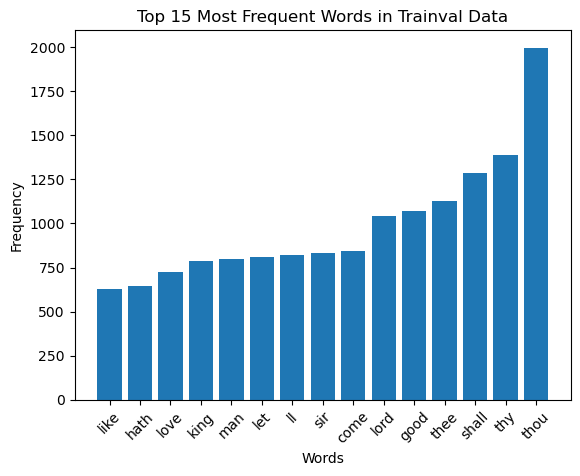

In [8]:
# Create a plot of the top 15 most frequently used words 

tokencounts = np.asarray(dtm_trainval.sum(axis=0)).ravel()
top_15 = np.argsort(tokencounts)[-15:]

plt.bar(vocab[top_15], tokencounts[top_15])
plt.title("Top 15 Most Frequent Words in Trainval Data")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.xlabel("Words")
plt.show()


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Q1(e) - Explore the Data 

For the trainval text data, plot the top 15 most frequently used words in the histories and the comedies.  Put these two bar plots side-by-side to compare the results. 

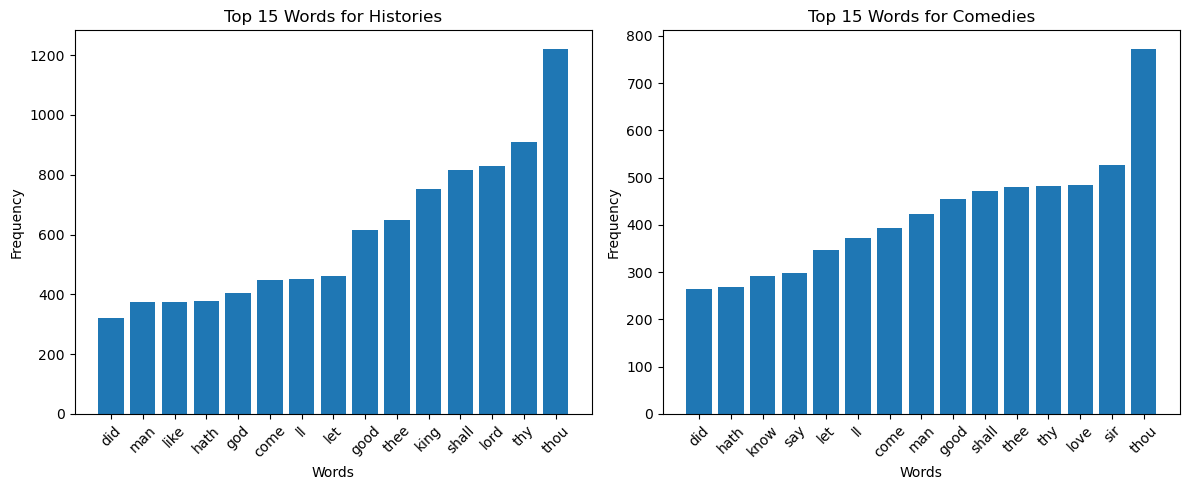

In [9]:
# Create a plot of the top 15 most frequently used words in the 
#  Comedies and Histories. 

# total counts per class label
history_counts = np.asarray(dtm_trainval[y_trainval == 1].sum(axis=0)).ravel()
comedy_counts  = np.asarray(dtm_trainval[y_trainval == 0].sum(axis=0)).ravel()

# top 15 indices for tokens
top_history = np.argsort(history_counts)[-15:]
top_comedy  = np.argsort(comedy_counts)[-15:]

# sort indices
history_order = np.argsort(history_counts[top_history])
comedy_order  = np.argsort(comedy_counts[top_comedy])

# make subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(vocab[top_history][history_order], history_counts[top_history][history_order])
axes[0].set_title("Top 15 Words for Histories")

axes[1].bar(vocab[top_comedy][comedy_order], comedy_counts[top_comedy][comedy_order])
axes[1].set_title("Top 15 Words for Comedies")

axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

axes[0].set_ylabel("Frequency")
axes[1].set_ylabel("Frequency")

axes[0].set_xlabel("Words")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()


<!-- END QUESTION -->

## Q1(f) - Bernoulli Naive Bayes 

Let's know explore using Bernoulli Naive Bayes as a classifier, `bern_nb`, to predict the type of play. 

We will use the split of the data into trainval / test found above to train the model and then evaluate it's performance. 

Create the training data, `X_trainval` to be binary with features using the default tokenizer, stop words removed, appear in at least 5 documents and is limited to the top 5000 features.  

Calculate the training accuracy `train_acc_bern` and testing accuracy `test_acc_bern` for the model.



In [10]:
# Run Bernoulli Naive Bayes model

# binary vectorizer
bin_vectorizer = CountVectorizer(
    stop_words="english",
    binary=True,
    min_df=5,
    max_features=5000
)

# fit on trainval, then transform both sets
X_trainval = bin_vectorizer.fit_transform(text_trainval)
X_test = bin_vectorizer.transform(text_test)

# train Bernoulli Naive Bayes
bern_nb = naive_bayes.BernoulliNB()
bern_nb.fit(X_trainval, y_trainval)

# find accuracies
train_acc_bern = bern_nb.score(X_trainval, y_trainval)
test_acc_bern = bern_nb.score(X_test, y_test)

print("Training accuracy:", train_acc_bern)
print("Testing accuracy:", test_acc_bern)



Training accuracy: 0.9501915708812261
Testing accuracy: 0.8636363636363636


In [11]:
grader.check("q1f")

q1f results: All test cases passed!

## Q1(g) - Multinomial Naive Bayes 

Let's know explore using multinomial Naive Bayes as a classifier, `mult_nb`, to predict the type of play. 

We will use the split of the data into trainval / test found above to train the model and then evaluate it's performance. 

Create the training data, `X_trainval` with features using the default tokenizer, stop words removed, appear in at least 5 documents and is limited to the top 5000 features.  

Calculate the training accuracy `train_acc_mult` and testing accuracy `test_acc_mult` for the model.


In [12]:
# Run Multinomial Naive Bayes model

# multinomial vectorizer
mult_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=5,
    max_features=5000
)

# fit on trainval, then transform both sets
X_trainval = mult_vectorizer.fit_transform(text_trainval)
X_test = mult_vectorizer.transform(text_test)

# train Bernoulli Naive Bayes
bern_nb = naive_bayes.MultinomialNB()
bern_nb.fit(X_trainval, y_trainval)

# find accuracies
train_acc_mult = bern_nb.score(X_trainval, y_trainval)
test_acc_mult = bern_nb.score(X_test, y_test)

print("Training accuracy:", train_acc_mult)
print("Testing accuracy:", test_acc_mult)


Training accuracy: 1.0
Testing accuracy: 0.9696969696969697


In [13]:
grader.check("q1g")

q1g results: All test cases passed!

## Q1(h) - Other Models 

Let's now look to explore using other models. 

You will set up a pipeline, `pipe`, that will use a Random Forest model with 100 trees and a `random_state` = 42.  

In the pipeline (`param_grid`), you will consider using both a document term count matrix as well as a TF-IDF matrix. 
In either case, limit the matrix to words that appear in at least 5 documents and remove English stop words.  Consider features of unigrams, unigrams + bigrams, and bigrams.  Examine a maximum feature limit of either 2500 or 5000.  

Optimize your choice of hyperparameters using GridSearchCV, `grid`, with stratified 5-fold cross-validation (random_state = 42), select the parameters using AUC. (See how to set up the scorer below)

Note, do not run the jobs in parallel, you may exceed the memory resources of the autograder on Gradescope. 

In [14]:
# Run Pipeline to find best model

pipe = Pipeline([
    ("vec", CountVectorizer()),
    ("rf", ensemble.RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

param_grid = [
    {
        "vec": [CountVectorizer(stop_words="english", min_df=5)],
        "vec__ngram_range": [(1, 1), (1, 2), (2, 2)],
        "vec__max_features": [2500, 5000]
    },
    {
        "vec": [TfidfVectorizer(stop_words="english", min_df=5)],
        "vec__ngram_range": [(1, 1), (1, 2), (2, 2)],
        "vec__max_features": [2500, 5000]
    }
]

cvStrat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score_fn = metrics.make_scorer(metrics.roc_auc_score, needs_threshold = False)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cvStrat,
    scoring=score_fn,
    n_jobs=1
)

grid.fit(text_trainval, y_trainval)

print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_))

/opt/anaconda3/envs/dmsp26/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Best cross-validation score: 0.88
Best parameters:
{'vec': TfidfVectorizer(min_df=5, stop_words='english'), 'vec__max_features': 2500, 'vec__ngram_range': (1, 2)}


In [15]:
grader.check("q1h")

q1h results: All test cases passed!

# Q2

Consider methods to cluster NBA players based on their statistics. 




## Q2(a) 

Load in data for NBA players from the 2018-2019 season. 

Filter the players to only consider those who have played in more than 20 games.  

Ignore the first 7 columns as well as ignore columns of statistics with percentages (FG%, 3P%, 2P%, eFG%, FT%). 

In [ ]:
# Load in data and filter out requested rows and columns.pri

nba = pd.read_csv("data/nba18-19.csv")
nba = nba[nba["G"]>20].drop(columns=["FG%", "3P%", "2P%", "eFG%", "FT%"])
nba.head()

In [ ]:
grader.check("q2a")

## Q2(b)

The features have different ranges, therefore we should scale the data before considering the clustering analysis. Scale the data using min-max normalization with range of [0, 1].

In [ ]:
# Scale the data 
nba2 = nba.iloc[:,7:]
scaler = MinMaxScaler()
nbaScaled = scaler.fit_transform(nba2)


In [ ]:
grader.check("q2b")

## Q2(c)

Run Kmeans clustering on the data with k=2, . . . , 12.  Set the `random_state` in the Kmeans method to 42 and `n_init` to 10. 
For each value of k, keep track of the within-cluster variation (this quantity is referred to as different terms such as “inertia” and total “within-cluster sum-of-squares”), the Calinski-Harabasz score, and the Davies-Bouldin index on the resulting clusters. 

In [ ]:
# Run Kmeans 

sse = []
dbscore = []
chscore = []

for k in range (2,11):
    kmeans = cluster.KMeans(n_clusters=k, random_state=42, n_init=10).fit(nbaScaled)
    sse.append(kmeans.inertia_)
    chscore.append(float(metrics.calinski_harabasz_score(nbaScaled, kmeans_fit)))
    dbscore.append(float(metrics.davies_bouldin_score(nbaScaled, kmeans_fit)))


In [ ]:
grader.check("q2c")

## Q2(d)

Assuming the best number of clusters is 4 (depending on which measure we use different number of clusters is preferred with this data). 

Run Kmeans again with this value for $k$ (use `n_init` = 10 and `random_state` = 10).

Create a DataFrame `clusterStats` with the mean statistics (centers) of each group. 

The DataFrame should have rows for each cluster group 0, 1, 2, 3 and columns for the mean statistics.  

Add a column `Num` reporting the number of samples in each group. 


In [ ]:
# Create a Data Frame for the mean statistics of each group 
kmeans = cluster.KMeans(n_clusters=4, n_init=10, random_state=10).fit(nbaScaled)
nbaClustered = pd.DataFrame(nbaScaled)
nbaClustered["cluster"] = kmeans.labels_

clusterStats = pd.DataFrame([
    [len(nbaClustered[nbaClustered["cluster"] == 0]), nbaClustered[nbaClustered["cluster"] == 0][0].mean(), nbaClustered[nbaClustered["cluster"] == 0][1].mean(), nbaClustered[nbaClustered["cluster"] == 0][2].mean(), nbaClustered[nbaClustered["cluster"] == 0][3].mean(), nbaClustered[nbaClustered["cluster"] == 0][4].mean(), nbaClustered[nbaClustered["cluster"] == 0][5].mean(), nbaClustered[nbaClustered["cluster"] == 0][6].mean(), nbaClustered[nbaClustered["cluster"] == 0][7].mean(), nbaClustered[nbaClustered["cluster"] == 0][8].mean(), nbaClustered[nbaClustered["cluster"] == 0][9].mean(), nbaClustered[nbaClustered["cluster"] == 0][10].mean(), nbaClustered[nbaClustered["cluster"] == 0][11].mean(), nbaClustered[nbaClustered["cluster"] == 0][12].mean(), nbaClustered[nbaClustered["cluster"] == 0][13].mean(), nbaClustered[nbaClustered["cluster"] == 0][14].mean(), nbaClustered[nbaClustered["cluster"] == 0][15].mean(), nbaClustered[nbaClustered["cluster"] == 0][16].mean(), nbaClustered[nbaClustered["cluster"] == 0][17].mean()],
    [len(nbaClustered[nbaClustered["cluster"] == 1]), nbaClustered[nbaClustered["cluster"] == 1][0].mean(), nbaClustered[nbaClustered["cluster"] == 1][1].mean(), nbaClustered[nbaClustered["cluster"] == 1][2].mean(), nbaClustered[nbaClustered["cluster"] == 1][3].mean(), nbaClustered[nbaClustered["cluster"] == 1][4].mean(), nbaClustered[nbaClustered["cluster"] == 1][5].mean(), nbaClustered[nbaClustered["cluster"] == 1][6].mean(), nbaClustered[nbaClustered["cluster"] == 1][7].mean(), nbaClustered[nbaClustered["cluster"] == 1][8].mean(), nbaClustered[nbaClustered["cluster"] == 1][9].mean(), nbaClustered[nbaClustered["cluster"] == 1][10].mean(), nbaClustered[nbaClustered["cluster"] == 1][11].mean(), nbaClustered[nbaClustered["cluster"] == 1][12].mean(), nbaClustered[nbaClustered["cluster"] == 1][13].mean(), nbaClustered[nbaClustered["cluster"] == 1][14].mean(), nbaClustered[nbaClustered["cluster"] == 1][15].mean(), nbaClustered[nbaClustered["cluster"] == 1][16].mean(), nbaClustered[nbaClustered["cluster"] == 1][17].mean()],
    [len(nbaClustered[nbaClustered["cluster"] == 2]), nbaClustered[nbaClustered["cluster"] == 2][0].mean(), nbaClustered[nbaClustered["cluster"] == 2][1].mean(), nbaClustered[nbaClustered["cluster"] == 2][2].mean(), nbaClustered[nbaClustered["cluster"] == 2][3].mean(), nbaClustered[nbaClustered["cluster"] == 2][4].mean(), nbaClustered[nbaClustered["cluster"] == 2][5].mean(), nbaClustered[nbaClustered["cluster"] == 2][6].mean(), nbaClustered[nbaClustered["cluster"] == 2][7].mean(), nbaClustered[nbaClustered["cluster"] == 2][8].mean(), nbaClustered[nbaClustered["cluster"] == 2][9].mean(), nbaClustered[nbaClustered["cluster"] == 2][10].mean(), nbaClustered[nbaClustered["cluster"] == 2][11].mean(), nbaClustered[nbaClustered["cluster"] == 2][12].mean(), nbaClustered[nbaClustered["cluster"] == 2][13].mean(), nbaClustered[nbaClustered["cluster"] == 2][14].mean(), nbaClustered[nbaClustered["cluster"] == 2][15].mean(), nbaClustered[nbaClustered["cluster"] == 2][16].mean(), nbaClustered[nbaClustered["cluster"] == 2][17].mean()],
    [len(nbaClustered[nbaClustered["cluster"] == 3]), nbaClustered[nbaClustered["cluster"] == 3][0].mean(), nbaClustered[nbaClustered["cluster"] == 3][1].mean(), nbaClustered[nbaClustered["cluster"] == 3][2].mean(), nbaClustered[nbaClustered["cluster"] == 3][3].mean(), nbaClustered[nbaClustered["cluster"] == 3][4].mean(), nbaClustered[nbaClustered["cluster"] == 3][5].mean(), nbaClustered[nbaClustered["cluster"] == 3][6].mean(), nbaClustered[nbaClustered["cluster"] == 3][7].mean(), nbaClustered[nbaClustered["cluster"] == 3][8].mean(), nbaClustered[nbaClustered["cluster"] == 3][9].mean(), nbaClustered[nbaClustered["cluster"] == 3][10].mean(), nbaClustered[nbaClustered["cluster"] == 3][11].mean(), nbaClustered[nbaClustered["cluster"] == 3][12].mean(), nbaClustered[nbaClustered["cluster"] == 3][13].mean(), nbaClustered[nbaClustered["cluster"] == 3][14].mean(), nbaClustered[nbaClustered["cluster"] == 3][15].mean(), nbaClustered[nbaClustered["cluster"] == 3][16].mean(), nbaClustered[nbaClustered["cluster"] == 3][17].mean()],
    ], columns=['Num', 'MP', 'FG', 'FGA', '3P', '3PA', '2P', '2PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'])

In [ ]:
grader.check("q2d")

## Q2(e)

Report the same statistics as in (e), but using the original data scaling (reverse the scaling back to the original data range). 

Store results in `clusterStatsOrig`; this DataFrame should not have the "Num" column.



In [ ]:
# Create a Data Frame for the mean statistics of each group (using the 
#   original data scaling)


kmeans = cluster.KMeans(n_clusters=4, n_init=10, random_state=10).fit(nbaScaled)
nbaClustered = pd.DataFrame(nba)
nbaClustered["cluster"] = kmeans.labels_

clusterStatsOrig = pd.DataFrame([
    [nbaClustered[nbaClustered["cluster"] == 0]["MP"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["FG"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["FGA"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["3P"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["3PA"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["2P"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["2PA"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["FT"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["FTA"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["ORB"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["DRB"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["TRB"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["AST"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["STL"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["BLK"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["TOV"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["PF"].mean(), nbaClustered[nbaClustered["cluster"] == 0]["PTS"].mean()],
    [nbaClustered[nbaClustered["cluster"] == 1]["MP"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["FG"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["FGA"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["3P"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["3PA"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["2P"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["2PA"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["FT"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["FTA"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["ORB"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["DRB"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["TRB"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["AST"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["STL"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["BLK"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["TOV"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["PF"].mean(), nbaClustered[nbaClustered["cluster"] == 1]["PTS"].mean()],
    [nbaClustered[nbaClustered["cluster"] == 2]["MP"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["FG"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["FGA"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["3P"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["3PA"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["2P"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["2PA"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["FT"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["FTA"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["ORB"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["DRB"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["TRB"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["AST"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["STL"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["BLK"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["TOV"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["PF"].mean(), nbaClustered[nbaClustered["cluster"] == 2]["PTS"].mean()],
    [nbaClustered[nbaClustered["cluster"] == 3]["MP"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["FG"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["FGA"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["3P"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["3PA"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["2P"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["2PA"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["FT"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["FTA"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["ORB"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["DRB"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["TRB"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["AST"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["STL"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["BLK"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["TOV"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["PF"].mean(), nbaClustered[nbaClustered["cluster"] == 3]["PTS"].mean()],
    ], columns=['MP', 'FG', 'FGA', '3P', '3PA', '2P', '2PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'])

In [ ]:
grader.check("q2e")

# Q3 : Clustering - Spotify Music

For this problem you will look at popular streaming music.  Specifically, Spotify's top 100 streaming songs.  For each song information about the song is described with different properties: `duration`, `energy`, `key`, etc. 


## Q3(a) - Load and Prepare the Data 

Load in the `music.csv` data.  

The clustering algorithms will only consider variables of `duration` to the end of the DataFrame. 

Standardize the variables to be used in clustering.  

In [ ]:
# Load in music data 

music = pd.read_csv("data/music.csv")
scaler = StandardScaler()
musicScaled = scaler.fit_transform(music.iloc[:, 5:])

music.head()

In [ ]:
grader.check("q3a")

## Q3(b) - Hierarchical Clustering 

Perform Hierarchical clustering with **single** linkage on just the top 30 songs. 

Report results in a dendrogram, `dg_single` and label the samples by the Artist.  



In [ ]:
# Perform Hierarchical clustering with single linkage on top 30 songs 
# Report results in a dendrogram, dg_single
model = hierarchy.linkage(musicScaled[:30], method="single")

plt.figure(figsize=(12, 6))
dg_single = dendrogram(model, truncate_mode="level", p=30, labels=music["Artist"][:30].tolist(), leaf_rotation=90)
plt.show()

In [ ]:
dg_single['leaves'][10:15]

In [ ]:
grader.check("q3b")

## Q3(c) - Hierarchical Clustering, part 2 

Perform Hierarchical clustering with **complete** linkage on just the top 30 songs.

Report results in a dendrogram, `dn_complete` and label the samples by the Artist.

In [ ]:
# Perform Hierarchical clustering with complete linkage on top 30 songs 
# Report results in a dendrogram, dg_complete
model = hierarchy.linkage(musicScaled[:30], method="complete")

plt.figure(figsize=(12, 6))
dg_complete = dendrogram(model, truncate_mode="level", p=30, labels=music["Artist"][:30].tolist(), leaf_rotation=90)
plt.show()

In [ ]:
grader.check("q3c")

## Q3(d) - Hierarchical Clustering, part 3

Perform Hierarchical clustering with **aveage** linkage on just the top 30 songs.

Report results in a dendrogram, `dn_average` and label the samples by the Artist.

In [ ]:
# Perform Hierarchical clustering with average linkage on top 30 songs 
# Report results in a dendrogram, dg_average
model = hierarchy.linkage(musicScaled[:30], method="average")

plt.figure(figsize=(12, 6))
dg_average = dendrogram(model, truncate_mode="level", p=30, labels=music["Artist"][:30].tolist(), leaf_rotation=90)
plt.show()

In [ ]:
grader.check("q3d")

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

**NOTE** the submission must be run on the campus linux machines.  See the instruction in the Canvas assignment.

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False)